**This Project Aims to Compare different ML Models on This DataSet**



**Part1: Data Loading**

Install All Packages and Libraries

In [2]:
#Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.decomposition import PCA
# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

**Data Explroation**

*First we have a glance at the head and then we check the info*

In [3]:
# Load the Dataset
df = pd.read_csv('/content/synthetic_fraud_dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [4]:
# Class distribution
print(df['Fraud_Label'].value_counts())
print("\nClass Distribution (%):")
class_dist = df['Fraud_Label'].value_counts(normalize=True) * 100
print(f"No fraud: {class_dist[0]:.2f}%")
print(f"Fraud: {class_dist[1]:.2f}%")

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Class Distribution (%):
No fraud: 67.87%
Fraud: 32.13%


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

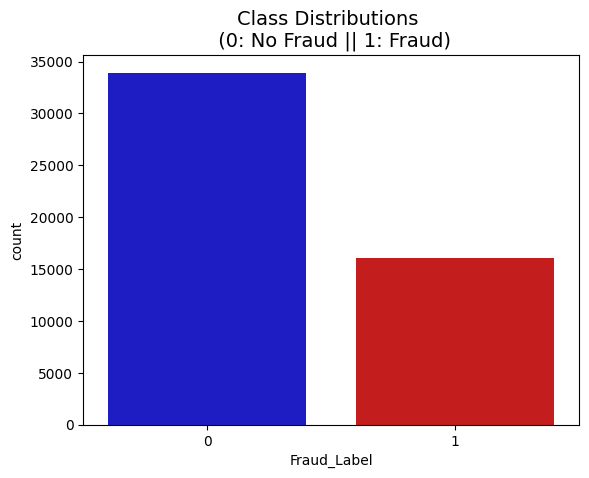

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Fraud_Label', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

*Check the info*

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

*Now we know there are categotical data and numerical one, let's go to data processing.*

**Part2: Data Processing**

Check Missing Values

In [7]:
print(df.isnull().sum())

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64


In [8]:
# Duplicate rows can lead to biased model training, so it's important to identify and remove them.
print("Number of duplicate rows before removal:", df.duplicated().sum())

Number of duplicate rows before removal: 0


In [9]:
# Convert Timestamp from string to datetime and note the inferred type
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Turning Timestamp into more useful features such as hour, day of week, and whether it was a weekend
df['Transaction_Hour'] = df['Timestamp'].dt.hour
df['Transaction_Day'] = df['Timestamp'].dt.day
df['Transaction_Month'] = df['Timestamp'].dt.month
df["Amount_Risk"] = df["Transaction_Amount"] * df["Risk_Score"]
df["Night_Transaction"] = (df["Transaction_Hour"] < 6).astype(int)
df["High_Daily_Count"] = (df["Daily_Transaction_Count"] > 10).astype(int)

In [10]:
df.shape

(50000, 27)

*Before we move on, let's first drop irrelevant columns like ID*

In [11]:
df = df.drop(columns=['Transaction_ID', 'User_ID','Timestamp','Risk_Score'])

Identify Categorical Data & Numerical Data

In [ ]:
df.info()

In [12]:
X = df.drop(columns=['Fraud_Label'])
y = df['Fraud_Label']

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

In [14]:
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (35000, 22)
Val: (5000, 22)
Test: (10000, 22)


In [15]:
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
numerical_columns = X.select_dtypes(include=['int64', 'float64','int32']).columns.tolist()

print('Categorical Columns:', categorical_columns)
print('Numerical Columns:', numerical_columns)

Categorical Columns: ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
Numerical Columns: ['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Is_Weekend', 'Transaction_Hour', 'Transaction_Day', 'Transaction_Month', 'Amount_Risk', 'Night_Transaction', 'High_Daily_Count']


Use OneHotEncoding on Categorical Data

In [16]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(X_train[categorical_columns])

X_train_cat = encoder.transform(X_train[categorical_columns])
X_val_cat   = encoder.transform(X_val[categorical_columns])
X_test_cat  = encoder.transform(X_test[categorical_columns])

Stadnardizae Numerical Values

In [17]:
scaler = RobustScaler()
scaler.fit(X_train[numerical_columns])

X_train_num = scaler.transform(X_train[numerical_columns])
X_val_num   = scaler.transform(X_val[numerical_columns])
X_test_num  = scaler.transform(X_test[numerical_columns])

Combine Processed Data

In [18]:
import numpy as np

X_train_processed = np.hstack([X_train_num, X_train_cat])
X_val_processed   = np.hstack([X_val_num, X_val_cat])
X_test_processed  = np.hstack([X_test_num, X_test_cat])

In [19]:
num_cols = numerical_columns
cat_cols = encoder.get_feature_names_out(categorical_columns)
all_features = list(num_cols) + list(cat_cols)

In [20]:
df_before_smote = pd.DataFrame(X_train_processed, columns=all_features)
for i, col in enumerate(df_before_smote.columns):
    print(i+1, col)

1 Transaction_Amount
2 Account_Balance
3 IP_Address_Flag
4 Previous_Fraudulent_Activity
5 Daily_Transaction_Count
6 Avg_Transaction_Amount_7d
7 Failed_Transaction_Count_7d
8 Card_Age
9 Transaction_Distance
10 Is_Weekend
11 Transaction_Hour
12 Transaction_Day
13 Transaction_Month
14 Amount_Risk
15 Night_Transaction
16 High_Daily_Count
17 Transaction_Type_ATM Withdrawal
18 Transaction_Type_Bank Transfer
19 Transaction_Type_Online
20 Transaction_Type_POS
21 Device_Type_Laptop
22 Device_Type_Mobile
23 Device_Type_Tablet
24 Location_London
25 Location_Mumbai
26 Location_New York
27 Location_Sydney
28 Location_Tokyo
29 Merchant_Category_Clothing
30 Merchant_Category_Electronics
31 Merchant_Category_Groceries
32 Merchant_Category_Restaurants
33 Merchant_Category_Travel
34 Card_Type_Amex
35 Card_Type_Discover
36 Card_Type_Mastercard
37 Card_Type_Visa
38 Authentication_Method_Biometric
39 Authentication_Method_OTP
40 Authentication_Method_PIN
41 Authentication_Method_Password


 Oversampling(SMOTE):

In [21]:
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

In [22]:
X_train_resampled.shape

(47506, 41)

**Part3: Model Training & Evaluation**

Split the Data into Training and Testing Sets

Algorithms:

In [36]:
from sklearn.ensemble import VotingClassifier
classification_models = {
    "Decision Tree": DecisionTreeClassifier(criterion="gini",max_depth=4,
                                            min_samples_split=10),
    "Logistic Regression": LogisticRegression(C=0.01),
    "SVM": SVC(C=0.3, kernel='rbf', gamma='scale',probability=True,
               class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=30),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,
                                                    max_depth=3,random_state=42),
    "Naive Bayes": GaussianNB(var_smoothing=1e-7)
}

In [37]:
train_rows = []
val_rows = []
test_rows = []
confusion_list = []
validation_confusion_list = []
train_list = []
roc_data = {}

In [38]:
# -------- Loop models --------
for model_name, model in classification_models.items():
    print(f"Processing: {model_name}")
    model.fit(X_train_resampled, y_train_resampled)

    # --- Train prediction ---
    y_train_pred = model.predict(X_train_resampled)
    train_acc = round(accuracy_score(y_train_resampled, y_train_pred)*100, 2)

    train_rows.append({
        "Model": model_name,
        "Train Accuracy (%)": train_acc
    })

    cm_train = confusion_matrix(y_train_resampled, y_train_pred)
    train_list.append((model_name, cm_train))

train_df = pd.DataFrame(train_rows).set_index("Model")

Processing: Decision Tree
Processing: Logistic Regression
Processing: SVM
Processing: KNN
Processing: Gradient Boosting
Processing: Naive Bayes


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import math

def plot_learning_curves_all_models(models, X_train, y_train,X_val, y_val,
                                    train_sizes=np.linspace(.1, 1.0, 5),cols=3):
    n = len(models)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).reshape(rows, cols)
    for i, (name, model) in enumerate(models.items()):
        r = i // cols
        c = i % cols
        ax = axes[r, c]
        train_scores = []
        val_scores   = []
        for frac in train_sizes:
            n_sub = int(frac * len(X_train))
            X_sub = X_train[:n_sub]
            y_sub = y_train[:n_sub]
            model.fit(X_sub, y_sub)
            train_pred = model.predict(X_sub)
            val_pred   = model.predict(X_val)
            train_scores.append(accuracy_score(y_sub, train_pred))
            val_scores.append(accuracy_score(y_val, val_pred))
        ax.plot(train_sizes*len(X_train), train_scores,'o-',label="Training")
        ax.plot(train_sizes*len(X_train), val_scores,'o-',label="Validation")
        ax.fill_between(
            train_sizes*len(X_train),
            np.array(train_scores)-0.01,
            np.array(train_scores)+0.01,
            alpha=0.1
        )

        ax.fill_between(
            train_sizes*len(X_train),
            np.array(val_scores)-0.01,
            np.array(val_scores)+0.01,
            alpha=0.1
        )
        ax.set_title(f"{name} Learning Curve")
        ax.set_xlabel("Training size")
        ax.set_ylabel("Accuracy")
        ax.grid(True)
        ax.legend()
    total = n
    for j in range(total, rows * cols):
        r = j // cols
        c = j % cols
        axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

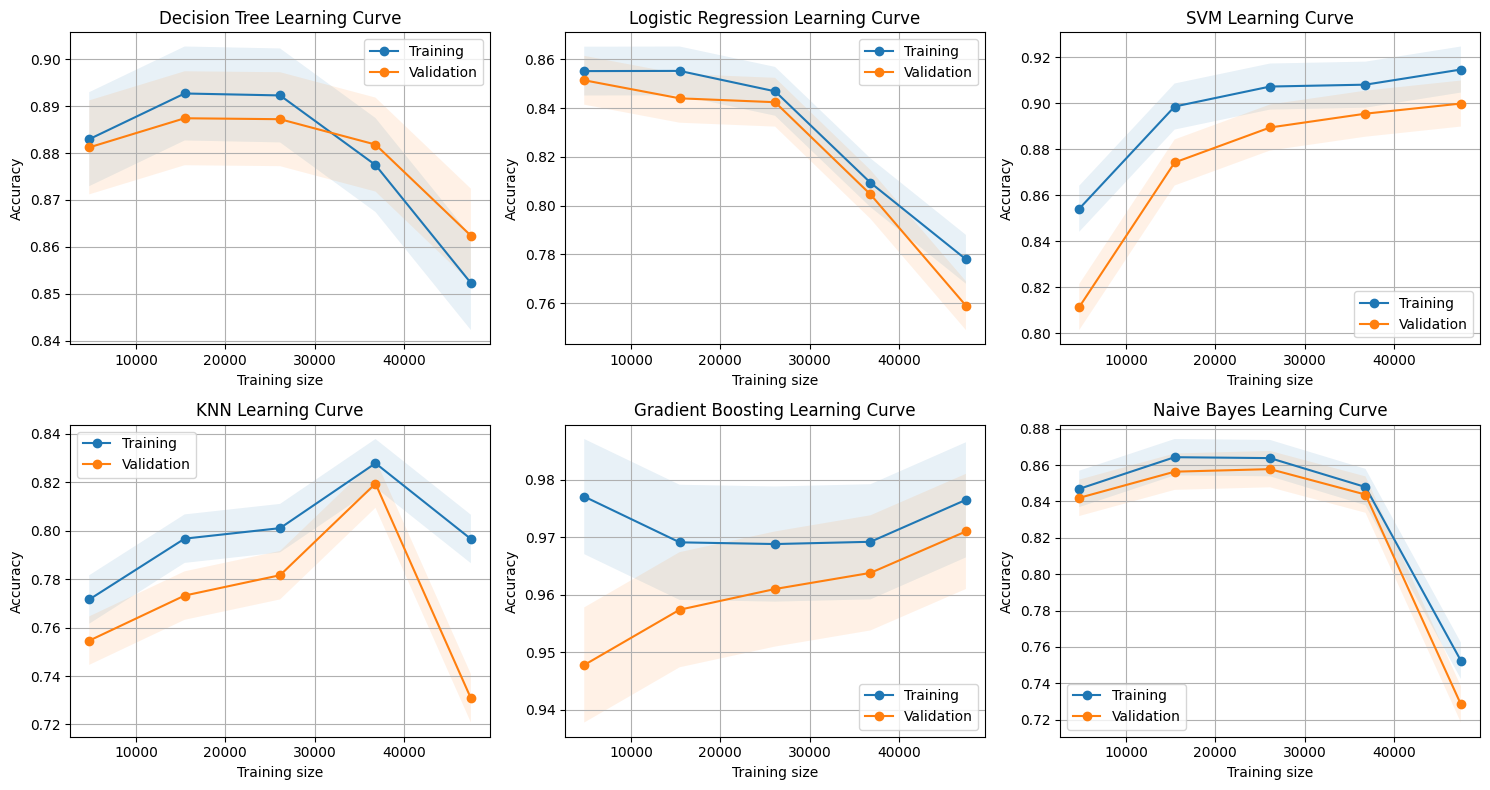

In [44]:
plot_learning_curves_all_models(
    classification_models,
    X_train_resampled,
    y_train_resampled,
    X_val_processed,
    y_val
)

In [39]:
# -------- Loop models --------
for model_name, model in classification_models.items():
    print(f"Processing: {model_name}")
    # Test predictions
    y_test_pred = model.predict(X_test_processed)
    y_test_proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else None

    test_rows.append({
        "Model": model_name,
        "Test Accuracy (%)": round(accuracy_score(y_test, y_test_pred)*100, 2),
        "Test Precision (%)": round(precision_score(y_test, y_test_pred, zero_division=0)*100, 2),
        "Test Recall (%)": round(recall_score(y_test, y_test_pred, zero_division=0)*100, 2),
        "Test F1 (%)": round(f1_score(y_test, y_test_pred, zero_division=0)*100, 2),
        "Test AUC (%)": round(roc_auc_score(y_test, y_test_proba)*100, 2) if y_test_proba is not None else None
    })

    cm = confusion_matrix(y_test, y_test_pred)
    confusion_list.append((model_name, cm))

    if y_test_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)
        auc_score = roc_auc_score(y_test, y_test_proba)
        roc_data[model_name] = (fpr, tpr, auc_score)

test_df = pd.DataFrame(test_rows).set_index("Model")

Processing: Decision Tree
Processing: Logistic Regression
Processing: SVM
Processing: KNN
Processing: Gradient Boosting
Processing: Naive Bayes


In [40]:
df_accuracy_comparison = pd.DataFrame({
    "Train Accuracy (%)": train_df["Train Accuracy (%)"],
    "Test Accuracy (%)": test_df["Test Accuracy (%)"]
})

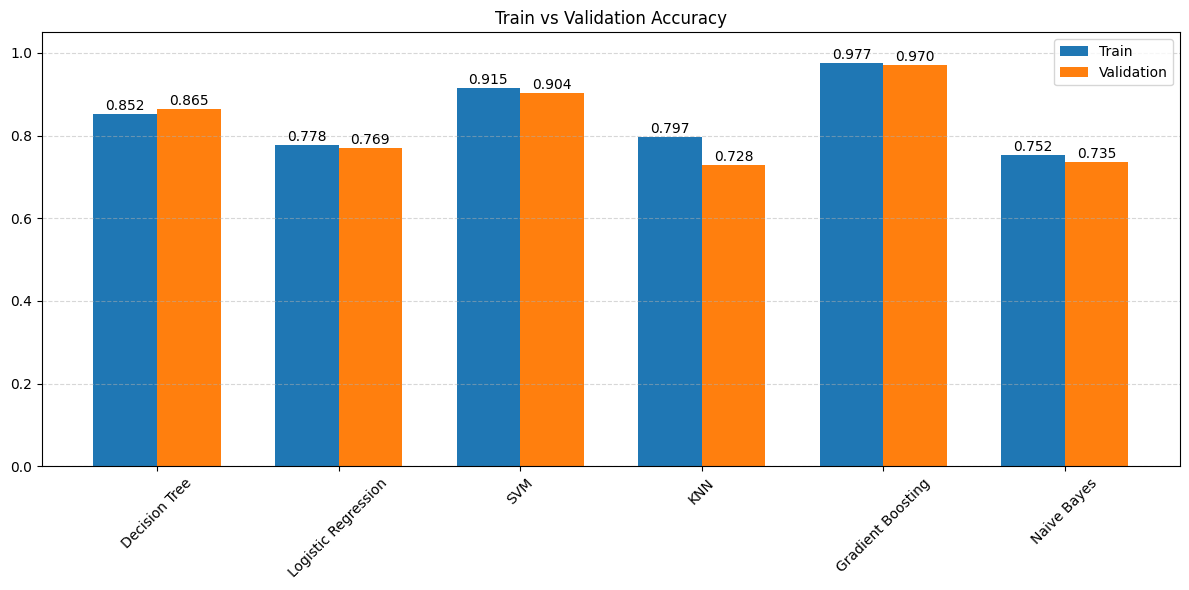

In [41]:
models = df_accuracy_comparison.index
train_acc = df_accuracy_comparison["Train Accuracy (%)"] / 100
val_acc = df_accuracy_comparison["Test Accuracy (%)"] / 100

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_acc, width, label='Train')
plt.bar(x + width/2, val_acc, width, label='Validation')

plt.xticks(x, models, rotation=45)
plt.ylim(0, 1.05)
plt.title("Train vs Validation Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(train_acc):
    plt.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center')
for i, v in enumerate(val_acc):
    plt.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center')

plt.legend()
plt.tight_layout()
plt.show()

In [42]:
print("\n===== Test Set Metrics =====")
test_df


===== Test Set Metrics =====


,Test Accuracy (%),Test Precision (%),Test Recall (%),Test F1 (%),Test AUC (%)
Model,,,,,
Decision Tree,86.48,80.94,75.75,78.26,93.00
Logistic Regression,76.90,61.01,77.87,68.42,86.21
SVM,90.39,84.08,86.46,85.25,96.02
KNN,72.81,55.18,81.89,65.93,83.80
Gradient Boosting,97.02,95.96,94.71,95.33,99.62
Naive Bayes,73.54,56.81,73.58,64.12,80.47


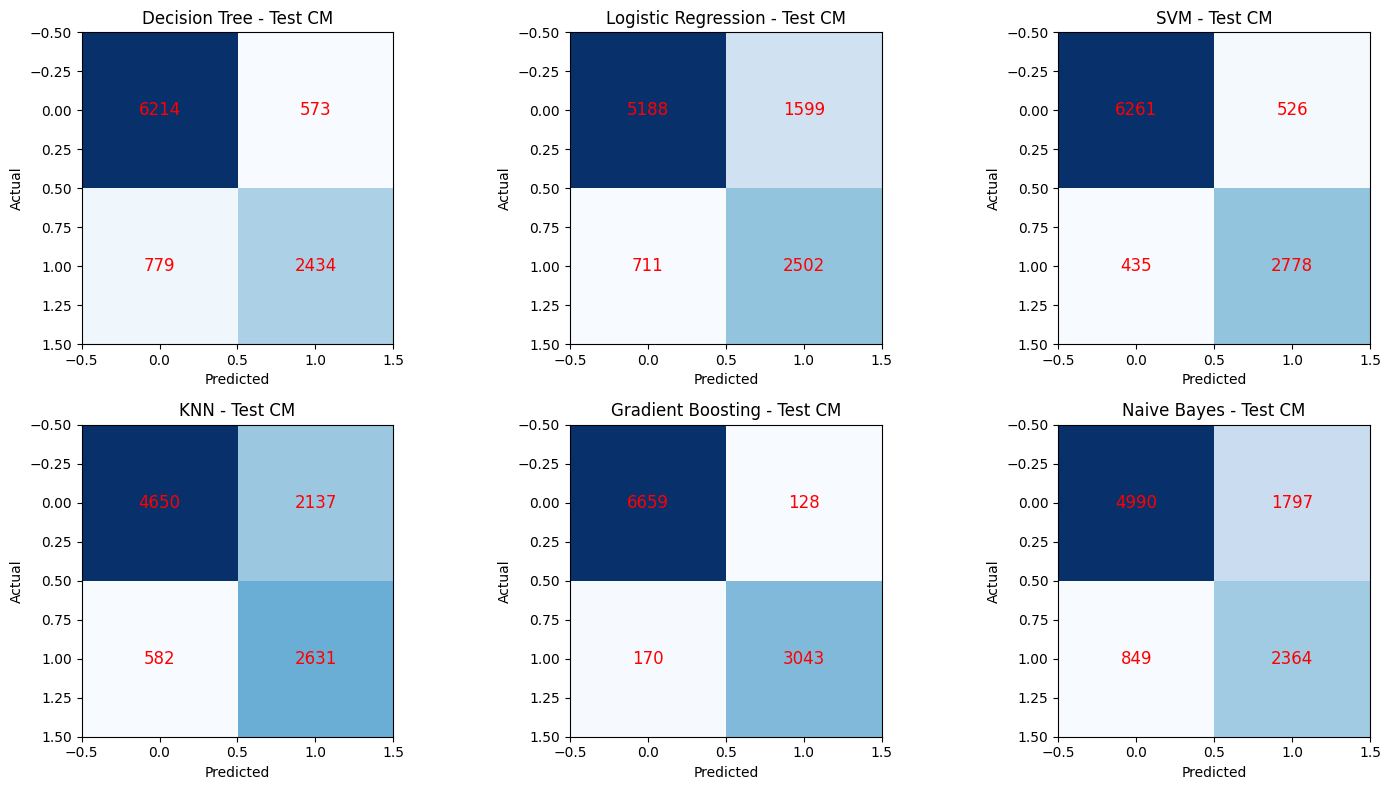

In [45]:
# --------- Plot confusion matrices in fixed layout: 3 top, 2 bottom ---------

n = len(confusion_list)
rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.array(axes).reshape(rows, cols)

for i, (model_name, cm) in enumerate(confusion_list):
    r = i // 3
    c = i % 3
    ax = axes[r, c]
    im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
    ax.set_title(f"{model_name} - Test CM")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for (j, k), val in np.ndenumerate(cm):
        ax.text(k, j, f"{val}", ha="center", va="center", color="red", fontsize=12)

if n < rows * cols:
    for j in range(n, rows*cols):
        r = j // cols
        c = j % cols
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

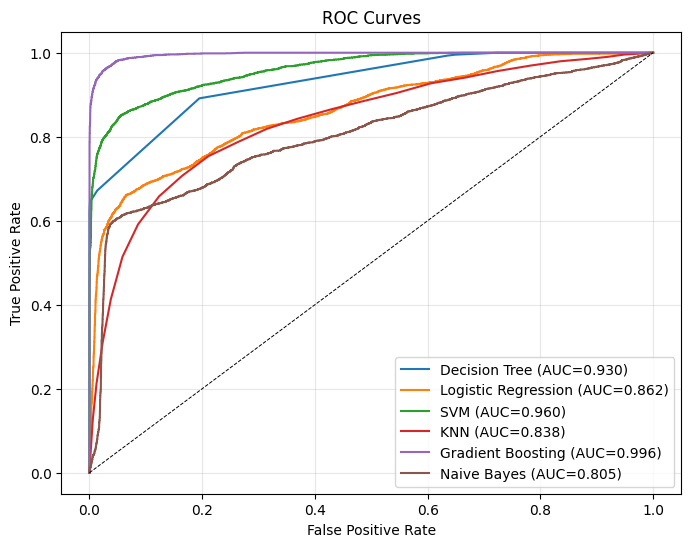

In [46]:
# --------- Plot ROC curves for all models (single figure) ---------
plt.figure(figsize=(8,6))
for name, (fpr, tpr, aucv) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={aucv:.3f})")
plt.plot([0,1],[0,1],'k--', linewidth=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()